# train

## import

In [1]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from auditoryforage.AF_env import AuditoryForaging as AF
from stable_baselines3 import PPO


## train

In [2]:
food_reward_list = [1000, 1100, 1200, 1300, 1400, 1500]
att_coeff = 0.087213
att_temp = 0.25
penalty_cost = -30
time_in_game_reward = 0.
# num_epochs = 11
# seed_value = 1

In [4]:

model_list={}
for food_reward in food_reward_list:
    # init
    task=AF()
    # assign values
    task.food_reward=food_reward
    task.time_in_game_reward=time_in_game_reward
    task.att_coeff=att_coeff
    task.att_temp=att_temp
    task.penalty_cost=penalty_cost
    # train
    model = PPO('MlpPolicy', task, verbose=1)
    model.learn(total_timesteps=10)
    # save
    model_list[food_reward]=model
    model.save(f'./ycstore/{food_reward}')


Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/home/yc/miniconda3/envs/ffneural/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 2.72     |
|    ep_rew_mean     | -31.8    |
| time/              |          |
|    fps             | 437      |
|    iterations      | 1        |
|    time_elapsed    | 4        |
|    total_timesteps | 2048     |
---------------------------------
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/home/yc/miniconda3/envs/ffneural/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 2.95     |
|    ep_rew_mean     | -24.7    |
| time/              |          |
|    fps             | 446      |
|    iterations      | 1        |
|    time_elapsed    | 4        |
|    total_timesteps | 2048     |
---------------------------------
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 2.77     |
|    ep_rew_mean     | -19.9    |
| time/              |          |
|    fps             | 445      |
|    iterations      | 1        |
|    time_elapsed    | 4        |
|    total_timesteps | 2048     |
---------------------------------
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 3        |
|    ep_rew_mean     | -24.3

## load and eval

In [74]:


def performance_reward_rate(model, task, total_trials=100 ):
    '''model reward rate'''
    history_r=[]
    for _ in range(total_trials):
        t=0
        total_r=0
        x=task.reset()
        done=False
        while not done: 
            # model.predict(x)
            a,_=model.predict(x)
            x, r, done, _ = task.step(a)
            t+=1
            total_r+=r
        history_r.append((total_r/t))
    return  history_r,
        

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Text(0.5, 0, 'food_reward')

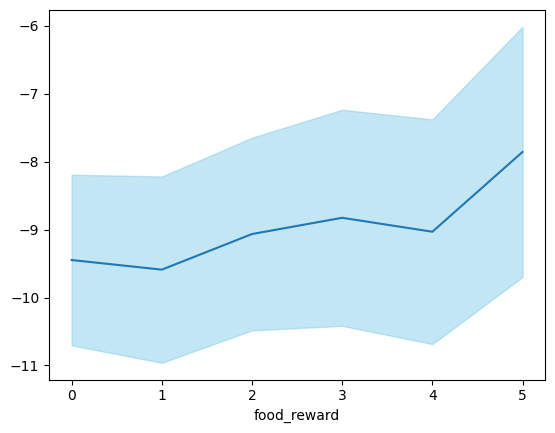

In [91]:
from collections import defaultdict
performances=defaultdict(list)
for food_reward in food_reward_list:
    # init
    task=AF()
    # assign values
    task.food_reward=food_reward
    task.time_in_game_reward=time_in_game_reward
    task.att_coeff=att_coeff
    task.att_temp=att_temp
    task.penalty_cost=penalty_cost
    # load
    model = PPO.load(f'ycstore/{food_reward}', env=task)
    model_list[food_reward]=model
    # eval
    performances['rewardrate'].append(performance_reward_rate(model, task,total_trials=1000)[0])
means=np.mean(np.array(performances['rewardrate']), axis=1)
stds=np.std(np.array(performances['rewardrate']), axis=1)*0.1
plt.fill_between(list(range(len(means))), means - stds, means + stds, color='skyblue', alpha=0.5, label='± 1 std')
plt.plot(list(range(len(means))), means)
plt.xlabel('food_reward')

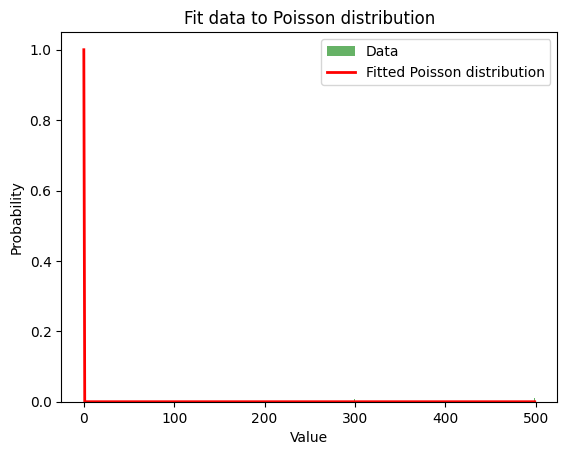

Estimated Poisson distribution parameter (mean): 1.7157112057664538e-05


In [66]:
import numpy as np
from scipy.stats import poisson
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Generate some example data
data = np.random.poisson(5, 1000)  # Generate Poisson-distributed data with mean of 5

data=np.array(performance(model, task, total_t=1000)[1])

# Define the Poisson probability mass function (PMF)
def poisson_pmf(x, mu):
    return poisson.pmf(x, mu)

x_values = np.arange(0, max(data) + 1)
hist_values, bin_edges = np.histogram(data, bins=np.arange(0, max(data) + 2))
mu_fit, _ = curve_fit(poisson_pmf, x_values, hist_values, p0=[5])

# Visualize the original data and the fitted Poisson distribution
plt.hist(data, bins=np.arange(0, max(data) + 1), density=True, alpha=0.6, color='g', label='Data')
x = np.arange(0, max(data) + 1)
plt.plot(x, poisson_pmf(x, mu_fit), 'r-', lw=2, label='Fitted Poisson distribution')
plt.xlabel('Value')
plt.ylabel('Probability')
plt.title('Fit data to Poisson distribution')
plt.legend()
plt.show()

print("Estimated Poisson distribution parameter (mean):", mu_fit[0])